In [1]:
# DO NOT CONTAINERISE
# =====
# Dependency
# -----
# ! pip install -r requirements.txt
# ! pip list
# ! conda list
# 
# !conda install numpy
# !conda install -c conda-forge numpy
# !pip install numpy

!pip install beacon-api
!pip install contextily

import os
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd

import requests

from beacon_api import *
import contextily as ctx

from pyproj import Transformer
from shapely.geometry import Point

# Surface temperature
param_exv_variable = "EXV002"

param_region = (0, 20, 45, 55)                   # lon_min, lon_max, lat_min, lat_max 
param_time   = ("2000-01-01", "2025-12-31")      # date_min, date_max
param_height = (0, 200)                          # elevation 


In [2]:
# IRISCC-Integrated Research Infrastructure Services for Climate Change Risks

url_BEACON_NODE_IRISCC = "https://beacon-iriscc.maris.nl"

client = Client(url_BEACON_NODE_IRISCC)
tables = client.list_tables()
# tables['actris-in-situ'].get_table_schema()


Connected to: https://beacon-iriscc.maris.nl/ server successfully
Beacon Version: 1.5.4


In [3]:
query_builder = tables["actris-in-situ"].query()

query_builder.add_select_column("time", "TIME")
query_builder.add_select_column('temperature')
query_builder.add_select_column('temperature.units',       'unit')
query_builder.add_select_column(".geospatial_lat_min",     'LATITUDE')
query_builder.add_select_column(".geospatial_lon_min",     'LONGITUDE')
query_builder.add_select_column(".ebas_station_altitude",  'HEIGHT')
query_builder.add_select_column(".ebas_framework_acronym", 'framework')
query_builder.add_select_column(".ebas_station_code",      "station_code")

query_builder.add_range_filter("TIME",      param_time[0],   param_time[1])
query_builder.add_range_filter("LONGITUDE", param_region[0], param_region[1])
query_builder.add_range_filter("LATITUDE",  param_region[2], param_region[3])
query_builder.add_range_filter("HEIGHT",    param_height[0], param_height[1])

query_builder.add_is_not_null_filter('temperature')
query_builder.add_range_filter('temperature', 273.15, 313.15)

df_actris = query_builder.to_pandas_dataframe()
df_actris['RI'] = 'ACTRIS'
#df_actris['EXV002'] = df_actris['EXV002'] - 273.15  # param_exv_variable

print(df_actris.describe())


Creating JSONQuery with from: FromTable(table='actris-in-situ')
Running query: {"output": {"format": "parquet"}, "select": [{"column": "time", "alias": "TIME"}, {"column": "temperature", "alias": null}, {"column": "temperature.units", "alias": "unit"}, {"column": ".geospatial_lat_min", "alias": "LATITUDE"}, {"column": ".geospatial_lon_min", "alias": "LONGITUDE"}, {"column": ".ebas_station_altitude", "alias": "HEIGHT"}, {"column": ".ebas_framework_acronym", "alias": "framework"}, {"column": ".ebas_station_code", "alias": "station_code"}], "filters": [{"column": "TIME", "gt_eq": "2000-01-01", "lt_eq": "2025-12-31"}, {"column": "LONGITUDE", "gt_eq": 0, "lt_eq": 20}, {"column": "LATITUDE", "gt_eq": 45, "lt_eq": 55}, {"column": "HEIGHT", "gt_eq": 0, "lt_eq": 200}, {"is_not_null": {"column": "temperature"}}, {"column": "temperature", "gt_eq": 273.15, "lt_eq": 313.15}], "distinct": null, "sort_by": null, "limit": null, "offset": null, "from": "actris-in-situ"}
                             TIM

In [4]:
import requests

def execute_sparql_query(endpoint, sparql_query):
    response = requests.get(
        endpoint,
        params={
            "query": sparql_query,
            "format": "application/sparql-results+json"
        },
        headers={
            "Accept": "application/sparql-results+json"
        }
    )
    
    response.raise_for_status()

    results = response.json()
    
    return results

def exv_to_p07(exv_code: str, return_preflabel: bool = False, cache: bool = True):
    url_NERC_VOC_EXV    = "http://vocab.nerc.ac.uk/collection/EXV/current"
    url_NERC_VOC_SPARQL = "https://vocab.nerc.ac.uk/sparql"
    
    exv_identifiers = map(lambda exv_code: f'<{url_NERC_VOC_EXV}/{exv_code}/>', [exv_code])
    exv_identifiers = "\n".join(exv_identifiers)
    
    sparql_query = f"""
    PREFIX dce: <http://purl.org/dc/elements/1.1/>
    PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
    PREFIX iadopt: <https://w3id.org/iadopt/ont#> 
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

    SELECT DISTINCT ?p07 ?prefLabel ?notation
    WHERE {{
        VALUES ?exv {{
            {exv_identifiers}
        }} 

        OPTIONAL {{?exv iadopt:hasApplicableMatrix ?matrix .}}
        ?exv iadopt:hasApplicableObjectOfInterest ?ooi .
        ?exv iadopt:hasApplicableProperty ?property .

        <http://vocab.nerc.ac.uk/collection/P07/current/> skos:member ?p07 .

        OPTIONAL {{ ?p07 iadopt:hasMatrix ?matrix . }}
        ?p07 iadopt:hasObjectOfInterest ?ooi .
        ?p07 iadopt:hasProperty ?property .

        OPTIONAL {{ ?p07 skos:prefLabel ?prefLabel .
                FILTER(LANG(?prefLabel) = "en")
        }}
        OPTIONAL {{ ?p07 skos:notation ?notation . }}
    }}
    """

    results = execute_sparql_query(url_NERC_VOC_SPARQL, sparql_query)
    
    return_val = []
    
    if return_preflabel:
        for result in results["results"]["bindings"]:
            preflabel = result.get("prefLabel", {}).get("value", "")
            return_val.append(preflabel)
            
    else:
        # Show results
        for result in results["results"]["bindings"]:
            uri = result.get("p07", {}).get("value", "")
            return_val.append(uri.rstrip("/").split("/")[-1])
   
    return return_val

#exv_to_p07("EXV002", return_preflabel = True)  # param_exv_variable


In [5]:
iagos_schema = tables['iagos-l2'].get_table_schema()

std_cols = [col for col in iagos_schema.names if col.endswith('.standard_name')]

query_builder = tables["iagos-l2"].query()

for parameter in std_cols:
    query_builder.add_select_column(parameter)

IAGOS_variable_names = query_builder.to_pandas_dataframe()


Creating JSONQuery with from: FromTable(table='iagos-l2')
Running query: {"output": {"format": "parquet"}, "select": [{"column": "UTC_time.standard_name", "alias": null}, {"column": "lat.standard_name", "alias": null}, {"column": "lon.standard_name", "alias": null}, {"column": "baro_alt_AC.standard_name", "alias": null}, {"column": "baro_alt_AC_validity_flag.standard_name", "alias": null}, {"column": "radio_alt_AC.standard_name", "alias": null}, {"column": "radio_alt_AC_validity_flag.standard_name", "alias": null}, {"column": "air_press_AC.standard_name", "alias": null}, {"column": "air_press_AC_validity_flag.standard_name", "alias": null}, {"column": "air_temp_AC.standard_name", "alias": null}, {"column": "air_temp_AC_validity_flag.standard_name", "alias": null}, {"column": "air_speed_AC.standard_name", "alias": null}, {"column": "air_speed_AC_validity_flag.standard_name", "alias": null}, {"column": "ground_speed_AC.standard_name", "alias": null}, {"column": "ground_speed_AC_validity_

In [6]:
value = "air_temperature"

matches = [
    col.split('.')[0]   
    for col in IAGOS_variable_names.columns
    if col.endswith('.standard_name') and IAGOS_variable_names[col].eq(value).any()
]

matches


['air_temp_AC', 'air_temp_PM', 'air_temp_P1']

In [7]:
#tables["iagos-l1"].get_table_schema()

df_IAGOS_l1 =(
        tables["iagos-l1"]
        .query()
    
        .add_select_column('title')
        .add_select_column("processing_level")

        .add_select_column("UTC_time",          "TIME")
        .add_select_column("lon",               "LONGITUDE")
        .add_select_column("lat",               "LATITUDE")
        .add_select_column("baro_alt_AC",       "HEIGHT")
        .add_select_column("air_temp_AC",       'air_temp_aircraft')
        .add_select_column("air_temp_AC.units", 'air_temp_aircraft_unit')
        .add_select_column("flight_name")
    
        .add_range_filter("TIME",      param_time[0],   param_time[1])
        .add_range_filter("LONGITUDE", param_region[0], param_region[1])
        .add_range_filter("LATITUDE",  param_region[2], param_region[3])
        .add_range_filter("HEIGHT",    param_height[0], param_height[1])
    
        .add_range_filter('air_temp_aircraft', 273.15, 313.15)
        .to_pandas_dataframe()
    )

df_IAGOS_l1['RI'] = 'IAGOS'

print(df_IAGOS_l1.describe())
df_IAGOS_l1


Creating JSONQuery with from: FromTable(table='iagos-l1')
Running query: {"output": {"format": "parquet"}, "select": [{"column": "title", "alias": null}, {"column": "processing_level", "alias": null}, {"column": "UTC_time", "alias": "TIME"}, {"column": "lon", "alias": "LONGITUDE"}, {"column": "lat", "alias": "LATITUDE"}, {"column": "baro_alt_AC", "alias": "HEIGHT"}, {"column": "air_temp_AC", "alias": "air_temp_aircraft"}, {"column": "air_temp_AC.units", "alias": "air_temp_aircraft_unit"}, {"column": "flight_name", "alias": null}], "filters": [{"column": "TIME", "gt_eq": "2000-01-01", "lt_eq": "2025-12-31"}, {"column": "LONGITUDE", "gt_eq": 0, "lt_eq": 20}, {"column": "LATITUDE", "gt_eq": 45, "lt_eq": 55}, {"column": "HEIGHT", "gt_eq": 0, "lt_eq": 200}, {"column": "air_temp_aircraft", "gt_eq": 273.15, "lt_eq": 313.15}], "distinct": null, "sort_by": null, "limit": null, "offset": null, "from": "iagos-l1"}
                                TIME     LONGITUDE      LATITUDE  \
count          

,title,processing_level,TIME,LONGITUDE,LATITUDE,HEIGHT,air_temp_aircraft,air_temp_aircraft_unit,flight_name,RI
0,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2024-07-26 16:50:56.999999744,8.6044,50.0443,192.3000,296.35,K,2024072608180504,IAGOS
1,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2024-07-26 16:51:00.999999744,8.6004,50.0432,178.0000,296.35,K,2024072608180504,IAGOS
2,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2024-07-26 16:51:04.999999744,8.5968,50.0424,162.1000,296.95,K,2024072608180504,IAGOS
3,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2024-07-26 16:51:08.999999744,8.5930,50.0415,150.3000,296.95,K,2024072608180504,IAGOS
4,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2024-07-26 16:51:12.999999744,8.5892,50.0405,132.9000,297.15,K,2024072608180504,IAGOS
...,...,...,...,...,...,...,...,...,...,...
12100,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2025-11-08 21:36:19.999999744,8.5261,50.0158,61.8744,279.15,K,2025110821355507,IAGOS
12101,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2025-11-08 21:36:23.999999744,8.5261,50.0127,48.7680,279.45,K,2025110821355507,IAGOS
12102,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2025-11-08 21:36:27.999999744,8.5261,50.0095,83.5152,279.15,K,2025110821355507,IAGOS
12103,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2025-11-08 21:36:31.999999744,8.5264,50.0062,143.8656,278.95,K,2025110821355507,IAGOS


In [8]:
df_IAGOS_l2 =(
        tables["iagos-l2"]
        .query()
    
        .add_select_column('title')
        .add_select_column("processing_level")
    
        .add_select_column("lon",               "LONGITUDE")
        .add_select_column("lat",               "LATITUDE")
        .add_select_column("UTC_time",          "TIME")
        .add_select_column("baro_alt_AC",       "HEIGHT")
        .add_select_coalesced(['air_temp_PM',       'air_temp_P1'],       'air_temp_IAGOS')
        .add_select_coalesced(['air_temp_PM.units', 'air_temp_P1.units'], 'air_temp_IAGOS_units')
        .add_select_column("air_temp_AC",       'air_temp_aircraft')
        .add_select_column("air_temp_AC.units", 'air_temp_aircraft_unit')
    
        .add_range_filter("TIME",      param_time[0],   param_time[1])
        .add_range_filter("LONGITUDE", param_region[0], param_region[1])
        .add_range_filter("LATITUDE",  param_region[2], param_region[3])
        .add_range_filter("HEIGHT",    param_height[0], param_height[1])
    
        .add_range_filter('air_temp_IAGOS',    273.15, 313.15)
        .add_range_filter('air_temp_aircraft', 273.15, 313.15)
        .to_pandas_dataframe()
    )

df_IAGOS_l2['RI'] = 'IAGOS'

print(df_IAGOS_l2.describe())
df_IAGOS_l2


Creating JSONQuery with from: FromTable(table='iagos-l2')
Running query: {"output": {"format": "parquet"}, "select": [{"column": "title", "alias": null}, {"column": "processing_level", "alias": null}, {"column": "lon", "alias": "LONGITUDE"}, {"column": "lat", "alias": "LATITUDE"}, {"column": "UTC_time", "alias": "TIME"}, {"column": "baro_alt_AC", "alias": "HEIGHT"}, {"function": "coalesce", "args": [{"column": "air_temp_PM", "alias": null}, {"column": "air_temp_P1", "alias": null}], "alias": "air_temp_IAGOS"}, {"function": "coalesce", "args": [{"column": "air_temp_PM.units", "alias": null}, {"column": "air_temp_P1.units", "alias": null}], "alias": "air_temp_IAGOS_units"}, {"column": "air_temp_AC", "alias": "air_temp_aircraft"}, {"column": "air_temp_AC.units", "alias": "air_temp_aircraft_unit"}], "filters": [{"column": "TIME", "gt_eq": "2000-01-01", "lt_eq": "2025-12-31"}, {"column": "LONGITUDE", "gt_eq": 0, "lt_eq": 20}, {"column": "LATITUDE", "gt_eq": 45, "lt_eq": 55}, {"column": "HEI

,title,processing_level,LONGITUDE,LATITUDE,TIME,HEIGHT,air_temp_IAGOS,air_temp_IAGOS_units,air_temp_aircraft,air_temp_aircraft_unit,RI
0,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,8.6200,50.0500,2010-09-11 06:05:20.999999744,191.1,287.440002,K,287.65,K,IAGOS
1,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,8.6100,50.0500,2010-09-11 06:05:26.999999744,169.2,287.350006,K,287.90,K,IAGOS
2,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,8.6100,50.0500,2010-09-11 06:05:30.999999744,151.8,287.329987,K,287.65,K,IAGOS
3,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,8.6100,50.0500,2010-09-11 06:05:34.999999744,134.1,287.339996,K,287.90,K,IAGOS
4,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,8.6000,50.0500,2010-09-11 06:05:38.999999744,117.3,287.399994,K,287.90,K,IAGOS
...,...,...,...,...,...,...,...,...,...,...,...
147181,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,8.5262,50.0079,2022-10-31 12:07:10.999999744,39.0,290.000000,K,289.95,K,IAGOS
147182,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,8.5262,50.0046,2022-10-31 12:07:14.999999744,70.1,289.940002,K,289.95,K,IAGOS
147183,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,8.5262,50.0015,2022-10-31 12:07:18.999999744,99.4,289.989990,K,289.65,K,IAGOS
147184,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,8.5264,49.9983,2022-10-31 12:07:22.999999744,135.6,289.820007,K,289.35,K,IAGOS


In [9]:
df_IAGOS = pd.concat([df_IAGOS_l1, df_IAGOS_l2], axis=0).reset_index(drop=True)

df_IAGOS['air_temp_IAGOS']    = df_IAGOS['air_temp_IAGOS']    - 273.15
df_IAGOS['air_temp_aircraft'] = df_IAGOS['air_temp_aircraft'] - 273.15

print(df_IAGOS.describe())
df_IAGOS


                                TIME      LONGITUDE       LATITUDE  \
count                         159291  159291.000000  159291.000000   
mean   2016-10-15 19:07:25.926034432       7.226801      49.906061   
min    2010-01-02 14:12:35.999999744       1.723300      45.461400   
25%    2013-05-14 16:37:23.999999744       6.771700      50.004300   
50%    2016-05-29 09:05:56.999999744       8.526200      50.034500   
75%    2019-06-11 12:52:03.999999744       8.564500      50.043100   
max    2025-11-28 04:38:12.999999744      16.603900      53.655300   
std                              NaN       2.539000       0.722437   

              HEIGHT  air_temp_aircraft  air_temp_IAGOS  
count  159291.000000      159291.000000   147186.000000  
mean      106.716425          13.850467       13.330016  
min         0.000000           0.000000        0.000024  
25%        64.000000           8.200000        7.760004  
50%       107.000000          14.000000       13.420007  
75%       151.800000 

,title,processing_level,TIME,LONGITUDE,LATITUDE,HEIGHT,air_temp_aircraft,air_temp_aircraft_unit,flight_name,RI,air_temp_IAGOS,air_temp_IAGOS_units
0,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2024-07-26 16:50:56.999999744,8.6044,50.0443,192.3,23.2,K,2024072608180504,IAGOS,NaN,NaN
1,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2024-07-26 16:51:00.999999744,8.6004,50.0432,178.0,23.2,K,2024072608180504,IAGOS,NaN,NaN
2,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2024-07-26 16:51:04.999999744,8.5968,50.0424,162.1,23.8,K,2024072608180504,IAGOS,NaN,NaN
3,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2024-07-26 16:51:08.999999744,8.5930,50.0415,150.3,23.8,K,2024072608180504,IAGOS,NaN,NaN
4,IAGOS Intermediate Observational Data L1 - Tim...,Level 1 (Intermediate observational data): The...,2024-07-26 16:51:12.999999744,8.5892,50.0405,132.9,24.0,K,2024072608180504,IAGOS,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
159286,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,2022-10-31 12:07:10.999999744,8.5262,50.0079,39.0,16.8,K,NaN,IAGOS,16.850000,K
159287,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,2022-10-31 12:07:14.999999744,8.5262,50.0046,70.1,16.8,K,NaN,IAGOS,16.790002,K
159288,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,2022-10-31 12:07:18.999999744,8.5262,50.0015,99.4,16.5,K,NaN,IAGOS,16.839990,K
159289,IAGOS final quality controlled Observational D...,Level 2 (Final quality controlled observationa...,2022-10-31 12:07:22.999999744,8.5264,49.9983,135.6,16.2,K,NaN,IAGOS,16.670007,K


In [10]:
datasets_ICOS = client.list_datasets()
datasets_ICOS['icos/icos.bbf'].get_schema()


__entry_key: string
__chunk_index: uint64
Date/Time: timestamp[s]
Longitude: double
Longitude QC Flag: int64
Longitude QC Comment: string
Longitude Type: string
Latitude: double
Latitude QC Flag: int64
Latitude QC Comment: string
Latitude Type: string
Depth [m]: double
Depth [m] QC Flag: int64
Depth [m] QC Comment: null
Depth [m] Type: string
Temp [degC]: double
Temp [degC] QC Flag: int64
Temp [degC] QC Comment: string
Temp [degC] Type: string
P_sal [psu]: double
P_sal [psu] QC Flag: int64
P_sal [psu] QC Comment: string
P_sal [psu] Type: string
Temperature of Equilibration [degC]: double
Temperature of Equilibration [degC] QC Flag: int64
Temperature of Equilibration [degC] QC Comment: string
Temperature of Equilibration [degC] Type: string
Equilibrator Pressure: double
Equilibrator Pressure QC Flag: int64
Equilibrator Pressure QC Comment: string
Equilibrator Pressure Type: string
xCO2 In Water - Calibrated In Dry Air [umol mol-1]: double
xCO2 In Water - Calibrated In Dry Air [umol mol-

In [11]:
df_ICOS = (
        datasets_ICOS['icos/icos.bbf']
        .query()

        .add_select_column("Date/Time", "TIME")
        .add_select_column("Latitude",  "LATITUDE")
        .add_select_column("Longitude", "LONGITUDE")
        .add_select_column("Atmospheric Pressure [hPa]",    "HEIGHT")
        .add_select_column("Atmospheric Temperature [degC]", param_exv_variable)
    
        .add_range_filter("LONGITUDE", param_region[0], param_region[1])
        .add_range_filter("LATITUDE",  param_region[2], param_region[3])
        .add_range_filter("TIME",      param_time[0],   param_time[1])
        # .add_range_filter("HEIGHT",    param_height[0], param_height[1])
        .add_is_not_null_filter(param_exv_variable)
        .to_pandas_dataframe()
    )

df_ICOS['RI'] = "ICOS"

print(df_ICOS.describe())
df_ICOS


Creating JSONQuery with from: FromBBFDataset(paths=['icos/icos.bbf'])
Running query: {"output": {"format": "parquet"}, "select": [{"column": "Date/Time", "alias": "TIME"}, {"column": "Latitude", "alias": "LATITUDE"}, {"column": "Longitude", "alias": "LONGITUDE"}, {"column": "Atmospheric Pressure [hPa]", "alias": "HEIGHT"}, {"column": "Atmospheric Temperature [degC]", "alias": "EXV002"}], "filters": [{"column": "LONGITUDE", "gt_eq": 0, "lt_eq": 20}, {"column": "LATITUDE", "gt_eq": 45, "lt_eq": 55}, {"column": "TIME", "gt_eq": "2000-01-01", "lt_eq": "2025-12-31"}, {"is_not_null": {"column": "EXV002"}}], "distinct": null, "sort_by": null, "limit": null, "offset": null, "from": {"bbf": {"paths": ["icos/icos.bbf"]}}}
                             TIME      LATITUDE     LONGITUDE  HEIGHT  \
count                       35543  35543.000000  35543.000000     0.0   
mean   2023-01-04 06:35:43.758000     51.579989      2.993561     NaN   
min           2022-04-29 00:05:31     51.579000      2.9930

,TIME,LATITUDE,LONGITUDE,HEIGHT,EXV002,RI
0,2023-07-24 03:02:09,51.58,2.994,NaN,17.3,ICOS
1,2023-07-24 03:02:10,51.58,2.994,NaN,17.3,ICOS
2,2023-07-24 03:02:11,51.58,2.994,NaN,17.3,ICOS
3,2023-07-24 03:02:12,51.58,2.994,NaN,17.3,ICOS
4,2023-07-24 03:02:13,51.58,2.994,NaN,17.3,ICOS
...,...,...,...,...,...,...
35538,2023-06-30 19:02:34,51.58,2.993,NaN,17.3,ICOS
35539,2023-06-30 19:02:35,51.58,2.993,NaN,17.3,ICOS
35540,2023-06-30 19:02:36,51.58,2.993,NaN,17.3,ICOS
35541,2023-06-30 19:02:37,51.58,2.993,NaN,17.3,ICOS


In [12]:
# 
# temperature, air_temp_aircraft, air_temp_IAGOS, EXV002

df_merged = pd.concat([df_actris, df_IAGOS, df_ICOS], axis=0).reset_index(drop=True)
print(df_merged.describe())
df_merged


                                TIME   temperature      LATITUDE  \
count                        2126765  1.931931e+06  2.126765e+06   
mean   2015-12-29 03:02:24.827317248  2.956343e+02  4.916235e+01   
min              2001-06-14 14:30:00  2.731500e+02  4.546140e+01   
25%              2012-10-21 15:30:00  2.931500e+02  4.696667e+01   
50%              2015-10-16 08:30:00  2.954400e+02  5.002990e+01   
75%    2019-05-28 12:30:24.449999872  2.985400e+02  5.134000e+01   
max    2025-11-28 04:38:12.999999744  3.131500e+02  5.365530e+01   
std                              NaN  5.751823e+00  2.312181e+00   

          LONGITUDE  air_temp_aircraft  air_temp_IAGOS        EXV002  
count  2.126765e+06      159291.000000   147186.000000  35543.000000  
mean   9.357187e+00          13.850467       13.330016     16.470648  
min    1.723300e+00           0.000000        0.000024      1.907000  
25%    2.966000e+00           8.200000        7.760004     14.500000  
50%    8.544300e+00          14.

,TIME,temperature,unit,LATITUDE,LONGITUDE,HEIGHT,framework,station_code,RI,title,processing_level,air_temp_aircraft,air_temp_aircraft_unit,flight_name,air_temp_IAGOS,air_temp_IAGOS_units,EXV002
0,2001-06-14 14:30:00,293.0,K,51.065,13.741389,116.0 m,"ACTRIS, GUAN",DE0063K,ACTRIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2001-06-14 15:30:00,293.0,K,51.065,13.741389,116.0 m,"ACTRIS, GUAN",DE0063K,ACTRIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2001-06-14 16:30:00,293.0,K,51.065,13.741389,116.0 m,"ACTRIS, GUAN",DE0063K,ACTRIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2001-06-14 17:30:00,293.0,K,51.065,13.741389,116.0 m,"ACTRIS, GUAN",DE0063K,ACTRIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2001-06-14 18:30:00,293.0,K,51.065,13.741389,116.0 m,"ACTRIS, GUAN",DE0063K,ACTRIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2126760,2023-06-30 19:02:34,NaN,NaN,51.580,2.993000,NaN,NaN,NaN,ICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.3
2126761,2023-06-30 19:02:35,NaN,NaN,51.580,2.993000,NaN,NaN,NaN,ICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.3
2126762,2023-06-30 19:02:36,NaN,NaN,51.580,2.993000,NaN,NaN,NaN,ICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.3
2126763,2023-06-30 19:02:37,NaN,NaN,51.580,2.993000,NaN,NaN,NaN,ICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.3


/tmp/ipykernel_54190/3523208530.py:51: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/conda/envs/ecvs/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


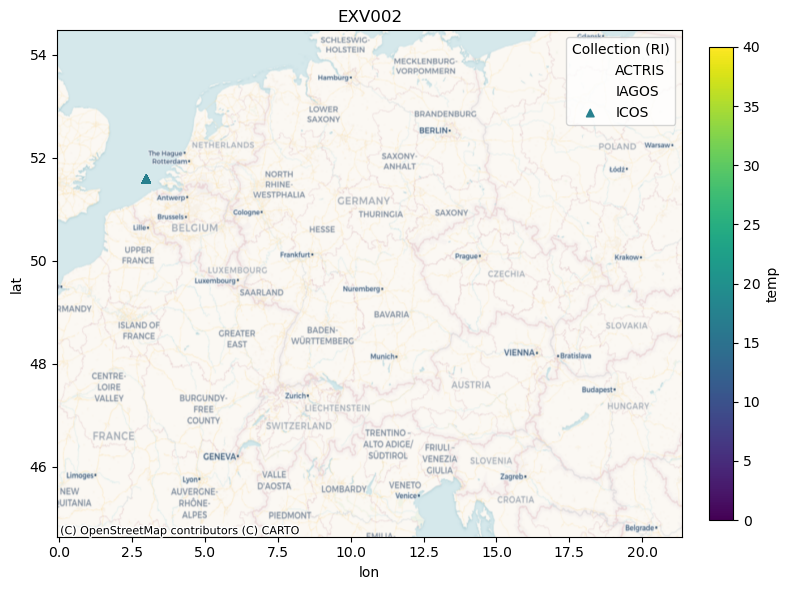

In [13]:
import contextily as ctx

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

markers = ["o", "s", "^"]  # circle, square, triangle

groups = list(df_merged.groupby("RI", observed=True))
groups = sorted(groups, key=lambda x: x[0] == "ICOS")

for (ri, group), marker in zip(groups, markers):

    is_icos = ri == "ICOS"

    sc = ax.scatter(
        group["LONGITUDE"],
        group["LATITUDE"],
        c=group["EXV002"],  # param_exv_variable
        cmap="viridis",
        s=30 if is_icos else 10,
        alpha=1.0 if is_icos else 0.6,
        marker=marker,
        label=ri,
        vmin=0,
        vmax=40,
        zorder=3 if is_icos else 2
    )

xmin, xmax = df_merged["LONGITUDE"].min(), df_merged["LONGITUDE"].max()
ymin, ymax = df_merged["LATITUDE"].min(),  df_merged["LATITUDE"].max()
pad_x = (xmax - xmin) * 0.1
pad_y = (ymax - ymin) * 0.1

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager,
    crs="EPSG:4326"
)

ax.legend(title="Collection (RI)")

ax.set_title("EXV002")
ax.set_xlabel("lon")
ax.set_ylabel("lat")

cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("temp")

plt.tight_layout()
plt.show()

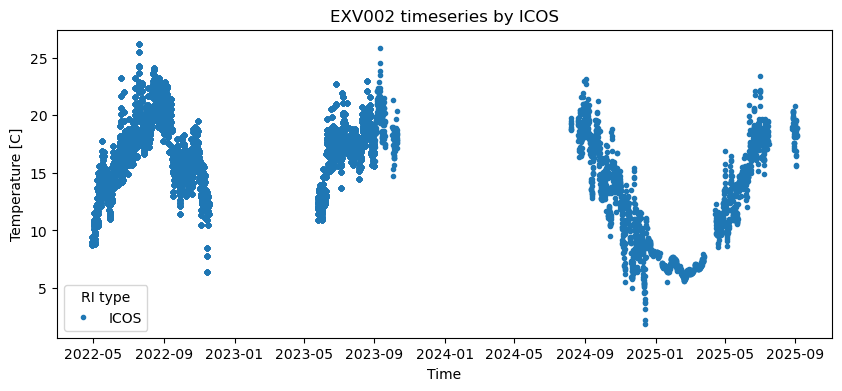

In [14]:
plt.figure(figsize=(10, 4), dpi=100)
plt.plot(df_ICOS['TIME'], df_ICOS['EXV002'], '.', label='ICOS')  # param_exv_variable
plt.xlabel('Time')
plt.ylabel('Temperature [C]')
plt.legend(title='RI type')
plt.title('EXV002 timeseries by ICOS')
plt.show()

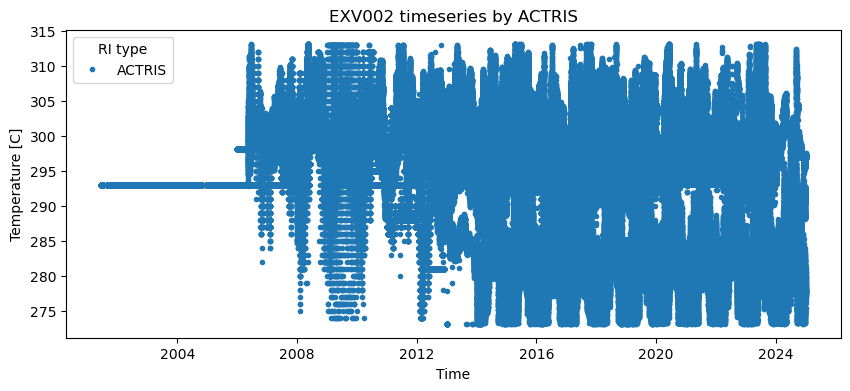

In [15]:
plt.figure(figsize=(10, 4), dpi=100)
# plt.plot(df_actris['TIME'], df_actris['EXV002'], '.', label='ACTRIS')  # param_exv_variable
plt.plot(df_actris['TIME'], df_actris['temperature'], '.', label='ACTRIS')
plt.xlabel('Time')
plt.ylabel('Temperature [C]')
plt.legend(title='RI type')
plt.title('EXV002 timeseries by ACTRIS')
plt.show()

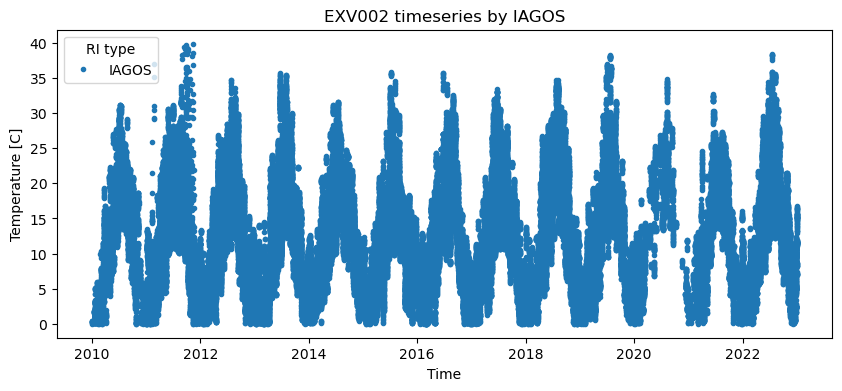

In [16]:
plt.figure(figsize=(10, 4), dpi=100)
plt.plot(df_IAGOS['TIME'], df_IAGOS['air_temp_IAGOS'], '.', label='IAGOS')  # param_exv_variable, KeyError: 'EXV002'
# air_temp_aircraft  air_temp_IAGOS
plt.xlabel('Time')
plt.ylabel('Temperature [C]')
plt.legend(title='RI type')
plt.title('EXV002 timeseries by IAGOS')
plt.show()

In [17]:
plt.figure(figsize=(10, 4), dpi=100)
for param in [
    'air_temp_AC',
    'air_stag_temp_PM',
    'air_stag_temp_AC',
    'air_temp_PM',
    'air_temp_P1',
    'air_stag_temp_P1']:
    plt.plot(df_IAGOS['TIME'], df_IAGOS[param], '.', label=f"IAGOS-{param}")


plt.xlabel('Time')
plt.ylabel('Temperature [C]')
plt.legend(title='RI type')
plt.title('EXV002 timeseries by IAGOS')
plt.show()

KeyError: 'air_temp_AC'

<Figure size 1000x400 with 0 Axes>